# 長榮海運 (2603.TW) 明日漲跌預測系統 — 合併版 Notebook

本 Notebook 由兩份檔案合併而成：
- `text_main.py`（後端）：Yahoo Finance 資料下載、特徵工程、決策樹模型訓練與評估
- `text_gardio.py`（前端）：Gradio 互動介面、K 線走勢圖與線上模型訓練

## 功能總覽
1. **讀取當日最新股票資料**：自動下載長榮海運 (2603.TW) 歷史日交易資料
2. **特徵工程**：20 日均線、乖離率、均線差、報酬率、振幅、價差、星期
3. **完整模型訓練流程**：決策樹 DecisionTreeClassifier，時間序切分訓練/測試集
4. **模型評估**：準確率、混淆矩陣、分類報告、特徵重要度
5. **即時預測**：以最新一筆資料推論明日漲跌與上漲/下跌機率
6. **視覺化**：K 線 + MA5/MA20 + 成交量組合圖
7. **Gradio 介面**：分頁式互動介面（即時預測 / 線上模型訓練 / 模型說明）

## 執行方式
由上而下依序執行所有 Cell。第一次執行會自動下載資料並訓練模型，需有網際網路連線。
資料為每日交易資料，**盤後執行**才能取得當日完整收盤資料。

> ⚠️ 本專案僅供學術研究與程式開發練習使用，不構成任何投資建議。


In [1]:
# 安裝相依套件（若已安裝可略過此 Cell）
!pip install yfinance pandas scikit-learn plotly gradio matplotlib -q



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Users\User\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [34]:
import os
import pandas as pd
import yfinance as yf
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import gradio as gr


In [35]:
# ===================== 設定與全域參數 =====================

# 保留的最終特徵欄位 (相對指標 + 衍生特徵)
FEATURES = [
    '20MA',
    'BIAS_20',       # 20日乖離率 (相對指標)
    'MA_diff',       # 均線差值 (衍生指標)
    'daily_return',  # 當日報酬率 (百分比)
    'amplitude',     # 振幅 (相對比例)
    'spread',        # 當日價差
    'week',          # 星期 (週期變數)
]

DEFAULT_MODEL_PARAMS = {
    'criterion': 'gini',
    'max_depth': 3,
    'min_samples_split': 10,
    'min_samples_leaf': 5,
    'random_state': 42,
    'test_size': 0.3,
}

# 全域變數（執行 train_new_model 時建立）
X = y = df_clean = df_full = model = X_test = y_test = None
scaler = None
TEST_ACCURACY = 0.0
TEST_TRAIN_ACCURACY = 0.0


## 1. 讀取當日股票資料

從 Yahoo Finance 自動下載長榮海運 (2603.TW) 完整歷史日交易資料。


In [36]:
def load_data() -> pd.DataFrame:
    """
    從 Yahoo Finance 自動下載長榮海運 (2603.TW) 歷史日交易資料。
    """
    ticker = yf.Ticker("2603.TW")
    df = ticker.history(period="max")  # 抓取完整數據

    # 將 Yahoo 的英文欄位名稱轉換為較直觀的欄位名稱
    df = df.reset_index()
    df['date'] = df['Date'].dt.strftime('%Y-%m-%d')  # 日期轉成 YYYY-MM-DD 字串
    df = df.rename(columns={
        'Open': 'open',
        'High': 'max',
        'Low': 'min',
        'Close': 'close',
        'Volume': 'Trading_Volume'
    })

    # 衍生的基本欄位
    df['Trading_money'] = df['close'] * df['Trading_Volume']  # 成交金額
    df['Trading_turnover'] = 0
    df['week'] = pd.to_datetime(df['date']).dt.dayofweek       # 星期幾
    df['20MA'] = df['close'].rolling(window=20).mean()         # 20 日移動平均

    return df


In [37]:
# 執行資料下載，並查看最新一筆資料（含當日）
raw = load_data()
print(f"資料筆數: {len(raw):,}   |   最新資料日期: {raw['date'].iloc[-1]}")
raw.tail(3)


資料筆數: 6,617   |   最新資料日期: 2026-08-13


,Date,open,max,min,close,Trading_Volume,Dividends,Stock Splits,date,Trading_money,Trading_turnover,week,20MA
6614,2026-08-11 00:00:00+08:00,215.0,220.0,213.5,218.0,12061822,0.0,0.0,2026-08-11,2.629477e+09,0,1,204.200
6615,2026-08-12 00:00:00+08:00,217.0,217.0,213.0,214.5,9380371,0.0,0.0,2026-08-12,2.012090e+09,0,2,204.950
6616,2026-08-13 00:00:00+08:00,215.0,217.0,214.0,215.5,6043227,0.0,0.0,2026-08-13,1.302315e+09,0,3,205.725


## 2. 特徵工程

計算技術指標、**標準化特徵（z-score）** 與目標變數（明日收盤是否高於今日收盤）。


In [38]:
def build_features(df: pd.DataFrame):
    """
    特徵工程：在原始資料上計算各種技術指標與目標變數。

    回傳 (X, y, df_clean, df_full)：
      - X         : 特徵矩陣（只用 FEATURES 定義的欄位，且經 StandardScaler 標準化為 z-score）
      - y         : 目標標籤（1=明日上漲, 0=明日下跌/平盤）
      - df_clean  : 有完整特徵與目標、可拿來訓練的資料表
      - df_full   : 連最新一筆（今天，target 為空）都保留的完整資料表

    各衍生特徵的意義：
      - MA_5         : 5 日移動平均線
      - BIAS_20      : 20 日乖離率 = (收盤 - 20MA) / 20MA
      - MA_diff      : 短長均線差 = MA5 - MA20（多空排列判斷）
      - daily_return : 當日報酬率（漲跌百分比）
      - amplitude    : 振幅 = (最高 - 最低) / 開盤
      - spread       : 當日最高與最低的價差
      - target       : 明日收盤是否高於今日收盤（1=是, 0=否）
    """
    df = df.drop_duplicates().copy()

    # ---- 計算各技術指標（滾動視窗會讓前 N 天出現 NaN，之後會自動剔除）----
    df['MA_5'] = df['close'].rolling(window=5).mean()               # 5 日均線
    df['BIAS_20'] = (df['close'] - df['20MA']) / df['20MA']         # 20 日乖離率
    df['MA_diff'] = df['MA_5'] - df['20MA']                         # 均線差
    df['daily_return'] = df['close'].pct_change()                   # 當日報酬率
    df['amplitude'] = (df['max'] - df['min']) / df['open']          # 振幅
    df['spread'] = df['max'] - df['min']                            # 高低價差
    # 目標：明日收盤 > 今日收盤 則為 1，否則為 0
    df['target'] = (df['close'].shift(-1) > df['close']).astype('Int64')

    # df_full：保留包含最新一筆（今天）資料（特徵已算出，僅 target 為 null）
    df_full = df.dropna(subset=FEATURES).copy()

    # df_clean：用於模型訓練（需同時有特徵與 target）
    df_clean = df_full.dropna(subset=['target']).copy()
    df_clean['target'] = df_clean['target'].astype(int)

    # ---- 特徵標準化：將各特徵轉為平均數 0、標準差 1（z-score），消除量綱差異 ----
    # 以可訓練資料擬合 scaler，之後預測最新一筆時使用同一組參數轉換
    global scaler
    scaler = StandardScaler()
    X = pd.DataFrame(
        scaler.fit_transform(df_clean[FEATURES]),
        columns=FEATURES,
        index=df_clean.index,
    )
    y = df_clean['target']
    return X, y, df_clean, df_full


## 3. 模型訓練

以決策樹 DecisionTreeClassifier 進行完整訓練流程：
- 使用「按時間順序」切分訓練/測試集（前段訓練、後段測試），模擬「用過去預測未來」
- 可調整超參數：test_size、random_state、criterion、max_depth、min_samples_split、min_samples_leaf


In [39]:
def train_new_model(
    test_size: float = 0.2,
    random_state: int = 42,
    criterion: str = 'gini',
    max_depth: int = 3,
    min_samples_split: int = 10,
    min_samples_leaf: int = 5,
):
    """
    依指定超參數重新訓練決策樹模型，並更新全域模型。

    切分方式：使用「按時間順序」切分（前段訓練、後段測試），
    更能模擬「用過去預測未來」的真實情境。
    """
    global X, y, df_clean, df_full, model, X_test, y_test, TEST_ACCURACY, TEST_TRAIN_ACCURACY

    # 重新下載資料並做特徵工程
    X, y, df_clean, df_full = build_features(load_data())

    # 依時間順序切分訓練集 / 測試集
    train_size = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

    # 建立並訓練決策樹模型
    model = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state,
    )
    model.fit(X_train, y_train)

    # 計算訓練集與測試集的準確率
    TEST_ACCURACY = float(accuracy_score(y_test, model.predict(X_test)))
    TEST_TRAIN_ACCURACY = float(accuracy_score(y_train, model.predict(X_train)))

    # 對測試集做預測，產生混淆矩陣與分類報告
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    report = classification_report(y_test, y_pred, target_names=["下跌/平盤", "上漲"], digits=4)

    feature_importance = sorted(
        ({"feature": f, "importance": round(float(v), 4)}
         for f, v in zip(FEATURES, model.feature_importances_)),
        key=lambda t: -t["importance"],
    )

    return {
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test)),
        "accuracy": round(TEST_ACCURACY, 4),
        "train_accuracy": round(TEST_TRAIN_ACCURACY, 4),
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
        "feature_importance": feature_importance,
        "report": report,
        "params": {
            "test_size": test_size,
            "random_state": random_state,
            "criterion": criterion,
            "max_depth": max_depth,
            "min_samples_split": min_samples_split,
            "min_samples_leaf": min_samples_leaf,
        },
    }


In [40]:
# ===================== 執行完整訓練流程 =====================

train_result = train_new_model(**DEFAULT_MODEL_PARAMS)

print("=" * 50)
print("模型訓練完成（決策樹 DecisionTreeClassifier）")
print("=" * 50)
print(f"訓練樣本數        : {train_result['n_train']:,}")
print(f"測試樣本數        : {train_result['n_test']:,}")
print(f"資料總數          : {train_result['n_train'] + train_result['n_test']:,}")
print(f"測試集準確率      : {train_result['accuracy']:.4f}")
print(f"訓練集準確率      : {train_result['train_accuracy']:.4f}")
print(f"使用參數          : {train_result['params']}")
print()
print("=== 分類報告 (Classification Report) ===")
print(train_result["report"])
print()
print("=== 特徵重要度 (Feature Importance) ===")
pd.DataFrame(train_result["feature_importance"])


模型訓練完成（決策樹 DecisionTreeClassifier）
訓練樣本數        : 4,618
測試樣本數        : 1,980
資料總數          : 6,598
測試集準確率      : 0.5207
訓練集準確率      : 0.5879
使用參數          : {'test_size': 0.3, 'random_state': 42, 'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 10, 'min_samples_leaf': 5}

=== 分類報告 (Classification Report) ===
              precision    recall  f1-score   support

       下跌/平盤     0.5203    0.9395    0.6697      1024
          上漲     0.5267    0.0722    0.1270       956

    accuracy                         0.5207      1980
   macro avg     0.5235    0.5058    0.3983      1980
weighted avg     0.5234    0.5207    0.4076      1980


=== 特徵重要度 (Feature Importance) ===


,feature,importance
0,daily_return,0.3436
1,MA_diff,0.2611
2,20MA,0.2391
3,amplitude,0.1562
4,BIAS_20,0.0000
5,spread,0.0000
6,week,0.0000


## 3.1 模型評估圖表

以下三張圖分別呈現模型的 **特徵權重值（重要度）**、**混淆矩陣** 與 **決策樹結構**。


In [41]:
# ① 特徵權重值（重要度）長條圖
imp_sorted = pd.DataFrame(train_result["feature_importance"])

fig_importance = go.Figure(go.Bar(
    x=imp_sorted["importance"], y=imp_sorted["feature"], orientation="h",
    marker_color="#4cc9f0",
    text=[f"{v:.4f}" for v in imp_sorted["importance"]],
    textposition="outside",
))
fig_importance.update_layout(
    template="plotly_dark", height=420,
    title=dict(text="特徵權重值 (Feature Importance)", font=dict(color="#ffffff")),
    paper_bgcolor="#161b22", plot_bgcolor="#0d1117",
    xaxis=dict(title="重要度", title_font=dict(color="#ffffff"), tickfont=dict(color="#ffffff")),
    yaxis=dict(tickfont=dict(color="#ffffff")),
    margin=dict(l=10, r=60, t=50, b=10),
)
fig_importance.update_xaxes(range=[0, imp_sorted["importance"].max() * 1.25])
fig_importance.show()


In [42]:
# ② 混淆矩陣熱力圖
cm = train_result["confusion_matrix"]
z_cm = [[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]]

fig_cm = go.Figure(go.Heatmap(
    z=z_cm,
    x=["預測 下跌/平盤", "預測 上漲"],
    y=["實際 下跌/平盤", "實際 上漲"],
    colorscale="Viridis",
    text=z_cm, texttemplate="%{text}",
    zmin=0, zmax=max(map(max, z_cm)) or 1,
))
fig_cm.update_layout(
    template="plotly_dark", height=420,
    title=dict(text="混淆矩陣 (Confusion Matrix)", font=dict(color="#ffffff")),
    paper_bgcolor="#161b22", plot_bgcolor="#0d1117",
    xaxis=dict(tickfont=dict(color="#ffffff")),
    yaxis=dict(tickfont=dict(color="#ffffff")),
    margin=dict(l=10, r=60, t=50, b=10),
)
fig_cm.show()


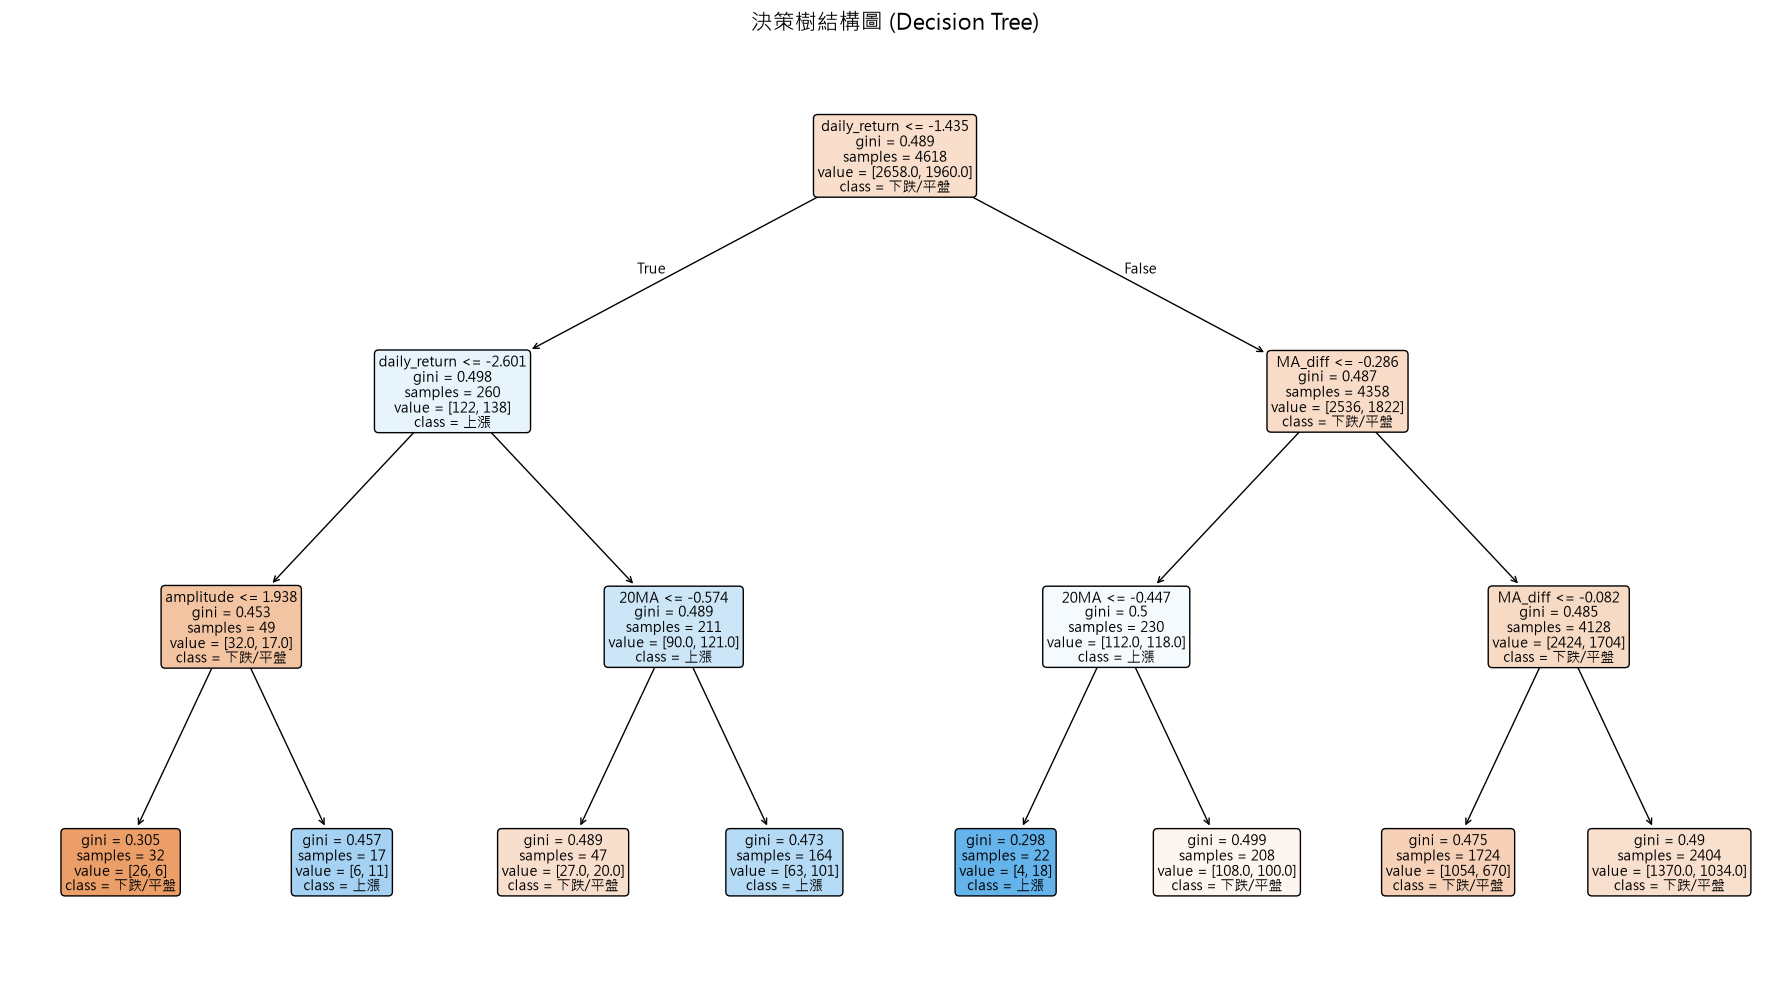

In [43]:
# ③ 決策樹結構圖
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

fig_tree, ax_tree = plt.subplots(figsize=(18, 10))
plot_tree(
    model,
    feature_names=FEATURES,
    class_names=["下跌/平盤", "上漲"],
    filled=True, rounded=True, fontsize=10,
    ax=ax_tree,
)
plt.title("決策樹結構圖 (Decision Tree)", fontsize=16)
plt.tight_layout()
plt.show()


## 4. 即時預測與行情函式

以最新一筆（包含今天）資料推論明日漲跌。


In [13]:
def get_latest_prediction() -> dict:
    """以最新一筆（包含今天）資料推論明日漲跌。"""
    latest_feature = scaler.transform(df_full[FEATURES].iloc[[-1]])
    pred = int(model.predict(latest_feature)[0])
    prob = model.predict_proba(latest_feature)[0]
    return {
        "date": str(df_full['date'].iloc[-1]),
        "prediction": pred,
        "signal": "【買進 / 看漲】" if pred == 1 else "【觀望 / 看跌或平盤】",
        "prob_down": round(float(prob[0]), 4),
        "prob_up": round(float(prob[1]), 4),
        "accuracy": round(TEST_ACCURACY, 4),
    }


def get_market_snapshot() -> dict:
    """最新兩筆行情快照，供前端展示。"""
    last = df_full.iloc[-1]
    prev = df_full.iloc[-2]
    change = float(last['close'] - prev['close'])
    change_pct = change / float(prev['close']) * 100
    return {
        "date": str(last['date']),
        "open": float(last['open']),
        "max": float(last['max']),
        "min": float(last['min']),
        "close": float(last['close']),
        "spread": change,
        "change_pct": round(change_pct, 2),
        "volume": float(last['Trading_Volume']),
        "money": float(last['Trading_money']),
        "turnover": float(last['Trading_turnover']),
        "ma20": float(last['20MA']),
        "ma5": float(last['MA_5']),
    }


def get_history_df(tail: int = 250) -> pd.DataFrame:
    """回傳歷史走勢資料 (收盤前 tail 筆)，並統一數值小數點位數為 2 位。"""
    cols = ['date', 'open', 'max', 'min', 'close', 'Trading_Volume', 'MA_5', '20MA']
    df_out = df_full[cols].tail(tail).reset_index(drop=True).copy()
    float_cols = ['open', 'max', 'min', 'close', 'MA_5', '20MA']
    df_out[float_cols] = df_out[float_cols].round(2)
    df_out['Trading_Volume'] = df_out['Trading_Volume'].astype(int)
    return df_out


In [14]:
# ===================== 顯示最新行情與明日預測 =====================

snapshot = get_market_snapshot()
prediction = get_latest_prediction()

print("=== 最新行情快照 ===")
print(f"日期              : {snapshot['date'][:10]}")
print(f"開盤/最高/最低/收盤 : {snapshot['open']:.2f} / {snapshot['max']:.2f} / {snapshot['min']:.2f} / {snapshot['close']:.2f}")
print(f"漲跌              : {snapshot['spread']:+.2f} ({snapshot['change_pct']:+.2f}%)")
print(f"成交量            : {snapshot['volume']:,} 股")
print(f"MA5 / MA20        : {snapshot['ma5']:.2f} / {snapshot['ma20']:.2f}")
print()
print("=== 明日漲跌預測 ===")
print(f"資料日期          : {prediction['date']}")
print(f"預測訊號          : {prediction['signal']}")
print(f"上漲機率          : {prediction['prob_up'] * 100:.2f}%")
print(f"下跌/平盤機率     : {prediction['prob_down'] * 100:.2f}%")
print(f"測試集準確率      : {prediction['accuracy'] * 100:.2f}%")


=== 最新行情快照 ===
日期              : 2026-08-13
開盤/最高/最低/收盤 : 215.00 / 217.00 / 214.00 / 215.50
漲跌              : +1.00 (+0.47%)
成交量            : 6,043,227.0 股
MA5 / MA20        : 213.90 / 205.72

=== 明日漲跌預測 ===
資料日期          : 2026-08-13
預測訊號          : 【觀望 / 看跌或平盤】
上漲機率          : 43.01%
下跌/平盤機率     : 56.99%
測試集準確率      : 52.07%


## 5. 視覺化 — K 線走勢圖

K 線 + MA5/MA20 移動平均線 + 成交量（紅=上漲、綠=下跌，符合台股慣例）。


In [15]:
def make_chart(tail: int = 180):
    """
    繪製「K 線 + MA5/MA20 + 成交量」組合圖。
    """
    df = get_history_df(tail)
    dates = df["date"].astype(str)

    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True,
        vertical_spacing=0.02, row_heights=[0.72, 0.28],
    )
    # K 線圖（紅=上漲、綠=下跌，符合台股慣例）
    fig.add_trace(go.Candlestick(
        x=dates, open=df["open"], high=df["max"], low=df["min"], close=df["close"],
        name="K線",
        increasing_line_color="#e64545", increasing_fillcolor="#e64545",
        decreasing_line_color="#00b378", decreasing_fillcolor="#00b378",
    ), row=1, col=1)
    # MA5（5 日線，金色）與 MA20（20 日線，藍色）
    fig.add_trace(go.Scatter(x=dates, y=df["MA_5"], name="MA5",
                             line=dict(color="#f0b90b", width=1.4)), row=1, col=1)
    fig.add_trace(go.Scatter(x=dates, y=df["20MA"], name="MA20",
                             line=dict(color="#4cc9f0", width=1.4)), row=1, col=1)

    # 成交量依當日漲跌上色（上漲紅、下跌綠）
    vol_colors = ["#e64545" if c >= o else "#00b378"
                  for o, c in zip(df["open"], df["close"])]
    fig.add_trace(go.Bar(x=dates, y=df["Trading_Volume"], name="成交量",
                         marker_color=vol_colors, opacity=0.55), row=2, col=1)

    fig.update_layout(
        template="plotly_dark",
        paper_bgcolor="#161b22",
        plot_bgcolor="#0d1117",
        height=540,
        xaxis_rangeslider_visible=False,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0,
                    font=dict(color="#ffffff")),
        margin=dict(l=50, r=20, t=30, b=30),
    )
    fig.update_xaxes(type="category", nticks=8, tickfont=dict(color="#ffffff"))
    fig.update_yaxes(tickfont=dict(color="#ffffff"))
    return fig


In [17]:
# 顯示近 180 日 K 線走勢圖
make_chart(180).show()


## 6. Gradio 互動介面

整合兩份原始檔案的前端功能（即時預測 / 線上模型訓練 / 模型說明），
在 Jupyter 中執行下下方的 Cell 後，瀏覽器開啟預設位址即可操作。


In [18]:
# ===================== Gradio 介面的輔助函式 =====================

def _snapshot_text() -> str:
    s = get_market_snapshot()
    return (
        f"日期: {s['date'][:10]}\n"
        f"開盤/最高/最低/收盤: {s['open']:.2f} / {s['max']:.2f} / {s['min']:.2f} / {s['close']:.2f}\n"
        f"漲跌: {s['spread']:+.2f} ({s['change_pct']:+.2f}%)\n"
        f"成交量: {s['volume']:,} 股\n"
        f"MA5 / MA20: {s['ma5']:.2f} / {s['ma20']:.2f}"
    )


def _prediction_text() -> str:
    p = get_latest_prediction()
    return (
        f"資料日期: {p['date']}\n"
        f"預測訊號: {p['signal']}\n"
        f"上漲機率: {p['prob_up'] * 100:.2f}%\n"
        f"下跌/平盤機率: {p['prob_down'] * 100:.2f}%\n"
        f"測試集準確率: {p['accuracy'] * 100:.2f}%"
    )


def run_training(test_size, random_state, criterion, max_depth, min_samples_split, min_samples_leaf):
    """執行線上模型訓練，回傳摘要文字、特徵重要度圖、混淆矩陣與分類報告。"""
    result = train_new_model(
        test_size=float(test_size),
        random_state=int(random_state),
        criterion=criterion,
        max_depth=int(max_depth),
        min_samples_split=int(min_samples_split),
        min_samples_leaf=int(min_samples_leaf),
    )
    acc = result["accuracy"] * 100
    train_acc = result["train_accuracy"] * 100
    n_total = result["n_train"] + result["n_test"]

    summary = (
        f"測試集準確率: {acc:.2f}%  |  訓練集準確率: {train_acc:.2f}%  |  "
        f"訓練樣本: {result['n_train']:,}  |  測試樣本: {result['n_test']:,}  |  "
        f"資料總數: {n_total:,}"
    )

    imp = pd.DataFrame(result["feature_importance"])
    imp_fig = go.Figure(go.Bar(
        x=imp["importance"], y=imp["feature"], orientation="h",
        marker_color="#4cc9f0",
        text=[f"{v:.3f}" for v in imp["importance"]],
        textposition="outside",
    ))
    imp_fig.update_layout(
        template="plotly_dark", height=400,
        title=dict(text="特徵重要度 Feature Importance", font=dict(color="#ffffff")),
        paper_bgcolor="#161b22",
        plot_bgcolor="#0d1117",
        xaxis=dict(title="重要度", title_font=dict(color="#ffffff"), tickfont=dict(color="#ffffff")),
        yaxis=dict(tickfont=dict(color="#ffffff")),
        margin=dict(l=10, r=60, t=50, b=10),
    )
    imp_fig.update_xaxes(range=[0, imp["importance"].max() * 1.25])

    cm = result["confusion_matrix"]
    z = [[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]]
    cm_fig = go.Figure(go.Heatmap(
        z=z, x=["預測 下跌/平盤", "預測 上漲"], y=["實際 下跌/平盤", "實際 上漲"],
        colorscale="Viridis", text=z, texttemplate="%{text}", zmin=0, zmax=max(map(max, z)) or 1,
    ))
    cm_fig.update_layout(
        template="plotly_dark", height=400,
        title=dict(text="混淆矩陣 Confusion Matrix", font=dict(color="#ffffff")),
        paper_bgcolor="#161b22",
        plot_bgcolor="#0d1117",
        xaxis=dict(tickfont=dict(color="#ffffff")),
        yaxis=dict(tickfont=dict(color="#ffffff")),
        margin=dict(l=10, r=60, t=50, b=10),
    )

    return summary, imp_fig, cm_fig, result["report"]


def refresh_live():
    """重新整理即時預測畫面。"""
    return _snapshot_text(), _prediction_text(), make_chart(180)


In [44]:
# ===================== 建立 Gradio 介面 =====================

with gr.Blocks(title="長榮海運 2603 明日漲跌預測") as demo:
    gr.Markdown("## 📊 長榮海運 (2603.TW) 明日漲跌預測")

    with gr.Tab("📊 即時預測"):
        with gr.Row():
            snap_box = gr.Textbox(label="最新行情快照", lines=5, value=_snapshot_text())
            pred_box = gr.Textbox(label="明日漲跌預測", lines=5, value=_prediction_text())
        live_chart = gr.Plot(label="近 180 日走勢", value=make_chart(180))
        refresh_btn = gr.Button("🔄 重新整理行情")
        refresh_btn.click(refresh_live, outputs=[snap_box, pred_box, live_chart])

    with gr.Tab("⚙️ 線上模型訓練"):
        with gr.Row():
            with gr.Column():
                test_size = gr.Slider(0.1, 0.5, value=0.3, step=0.05, label="測試集比例 test_size")
                random_state = gr.Number(value=42, label="隨機種子 random_state")
                criterion = gr.Dropdown(["gini", "entropy"], value="gini", label="分割準則 criterion")
                max_depth = gr.Slider(1, 20, value=3, step=1, label="樹最大深度 max_depth")
                min_samples_split = gr.Slider(2, 50, value=10, step=1, label="分裂所需樣本數 min_samples_split")
                min_samples_leaf = gr.Slider(1, 30, value=5, step=1, label="葉節點最少樣本 min_samples_leaf")
                train_btn = gr.Button("🚀 開始訓練", variant="primary")
            with gr.Column():
                summary_box = gr.Textbox(label="訓練摘要", lines=3)
                imp_fig = gr.Plot(label="特徵重要度")
                cm_fig = gr.Plot(label="混淆矩陣")
        report_box = gr.Textbox(label="分類報告 Classification Report", lines=8)
        train_btn.click(
            run_training,
            inputs=[test_size, random_state, criterion, max_depth, min_samples_split, min_samples_leaf],
            outputs=[summary_box, imp_fig, cm_fig, report_box],
        )

    with gr.Tab("📖 模型說明"):
        gr.Markdown("""
### 標的
長榮海運（2603.TW）

### 特徵工程
| 特徵 | 說明 |
|---|---|
| `20MA` | 20 日移動平均線 |
| `BIAS_20` | 20 日乖離率 = (收盤 - 20MA) / 20MA |
| `MA_diff` | 短長均線差 = MA5 - MA20 |
| `daily_return` | 當日報酬率 |
| `amplitude` | 振幅 = (最高 - 最低) / 開盤 |
| `spread` | 當日漲跌價差 |
| `week` | 星期（週期變數） |

### 模型
- 演算法：**決策樹 DecisionTreeClassifier**
- 預設參數：`criterion=gini, max_depth=3, min_samples_split=10, min_samples_leaf=5`
- 目標：以今日收盤預測「明日收盤是否上漲」

> ⚠️ 本系統僅供學術研究與程式開發練習使用，不構成任何投資建議。
""")


## 7. 啟動互動介面

執行下方 Cell 啟動 Gradio 介面（預設 http://127.0.0.1:7860）。
在「⚙️ 線上模型訓練」頁籤調整超參數後按「🚀 開始訓練」，
即可立即重新訓練並更新「即時預測」分頁的結果。


In [20]:
# ===================== 啟動 Gradio 介面 =====================
# 執行後會在本機開啟互動介面（預設 http://127.0.0.1:7860）
demo.launch(share=False)


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
